# MiniDog: Dog-Breed Text-to-Image Diffusion, from Pretraining to Fine-Tuning, on 4 Consumer GPUs

Training a diffusion transformer is usually presented as something that needs industrial-scale
compute. This notebook shows otherwise. It pretrains a text-to-image Diffusion Transformer (DiT)
from scratch to an FID below 10 in about 2.5 hours on 4x RTX 3090 (24GB), then fine-tunes it in 20
more minutes. At quoted Aug-2026 rental rates (Vast.ai \$0.25/GPU/hr, RunPod \$0.46/GPU/hr) the
whole pipeline costs roughly **\$3-\$5 of rented compute**.

No pretrained generative weights are distributed. Every checkpoint you end up with is one you
trained.

### The two tasks

**Task 1 - Diffusion basics.** Toy 2D data, on CPU, in minutes. It answers one question: should a
flow-matching model predict the clean data $x$ or the velocity $v$? That is the choice behind
`transport.prediction: 'velocity'` in every config used in Task 2.

**Task 2 - The full pipeline.** A two-stage text-to-image system trained on 26,000 recaptioned dog
images spanning 20 breeds. Stage 1 is a frozen VAE that compresses a 256x256 image to a 16x16x32
latent grid. Stage 2 is a DiT trained with flow matching to generate those latents from a caption.
The pretrained model is then fine-tuned on 2,000 curated synthetic images and evaluated three ways:
FID, Inception Score, and two learned human-preference models.

### How this notebook relates to the code

Every training, sampling, and evaluation step shells out to the
[diffusion-bench](https://github.com/Reyhaneesmailizadeh/diffusion-bench) repo. The commands here
are the ones that produced the reported results. Nothing is reimplemented in the notebook, so
anything you learn here transfers directly to the codebase, and any fix to the codebase applies
here.

### Prerequisites

PyTorch and `nn.Module`, plus a general sense of what a training loop looks like. Diffusion models
and transformer internals are built up from scratch in Task 1-7.

### Compute

Task 1 runs on CPU in seconds to a few minutes. Task 2 assumes four GPUs with 24GB each. The
commands shown are the full-scale ones, not a reduced toy version; adjust `--nproc_per_node` and
`CUDA_VISIBLE_DEVICES` for the machine you have.

# Task 1: Diffusion basics - flow matching on toy 2D data

*Adapted from the COMP4680/8650 (Advanced Topics in Machine Learning, ANU) assignment
"Flow Matching" - full assignment: [`COMP4680_8650_Flowmatching.pdf`](COMP4680_8650_Flowmatching.pdf),
reference implementation: [`toy_flow_matching/`](toy_flow_matching/).*

Before real images, text encoders, or a 12-block transformer, it helps to build the intuition on
data you can see directly: 2D points on a spiral, a ring of Gaussian blobs, two concentric circles.

This task answers one question: **should a flow-matching model predict the clean data $x$, or the
velocity $v$?** That is the exact setting of `transport.prediction` in every config used in Task 2,
so the answer decides how the real pipeline is parameterized. The throughline follows a toy-data
finding from *Back to Basics: Let Denoising Generative Models Denoise* (arXiv 2511.13720).

Task 1 is self-contained: toy datasets generated on the fly, no GPU, no downloads, and every cell
runs in seconds to a couple of minutes on CPU. The code lives in
[`toy_flow_matching/`](toy_flow_matching/), which ships with the repo.

It also runs in the same `uv sync` environment as Task 2, so one kernel covers the whole notebook.
(`toy_flow_matching/` carries its own `pyproject.toml` if you ever want to run it standalone, but
you do not need it here.)

## Setup (toy flow-matching project)

```bash
cd notebooks/toy_flow_matching
curl -LsSf https://astral.sh/uv/install.sh | sh   # install uv, if you don't have it
uv sync                                            # tiny env: torch, numpy, matplotlib, sklearn
uv run hf download xingjianleng/toy-data --local-dir data --repo-type dataset
```

Three 2D toy distributions ship in that dataset: `swiss_roll`, `gaussians` (an 8-mode ring),
and `circles` (two concentric rings). For each, the 2D points are also provided pre-projected
into higher ambient dimensions $D \in \{2, 8, 32\}$ via a random *orthogonal* matrix
$P_D$ of shape $(2, D)$ — this preserves each point's $L_2$ norm while embedding the
intrinsically-2D manifold into a $D$-dimensional space. The point of this construction: no
matter how large $D$ gets, the data's real complexity never changes — it's still just a 2D
spiral or ring, wearing a $D$-dimensional disguise. That gap between *ambient* and *intrinsic*
dimension is exactly what Part 2 below will show breaking one parameterization but not the
other.

In [2]:
import sys
from pathlib import Path

# Locate toy_flow_matching relative to this notebook, not to the kernel's working
# directory -- so it works whether Jupyter was launched from notebooks/ or from the
# repo root. Falls back to the CWD if __file__-style resolution is unavailable.
def _find(marker, start=None):
    here = Path(start or Path.cwd()).resolve()
    for d in [here, *here.parents]:
        if (d / marker).exists():
            return (d / marker).resolve()
    raise FileNotFoundError(
        f"Could not find {marker!r} above {here}. Run this notebook from inside a clone "
        "of https://github.com/Reyhaneesmailizadeh/diffusion-bench")

TOY_FM_ROOT = _find("notebooks/toy_flow_matching")
sys.path.insert(0, str(TOY_FM_ROOT))
print("toy_flow_matching:", TOY_FM_ROOT)

import matplotlib.pyplot as plt
from PIL import Image

def show_result(*filenames, figsize=(14, 6)):
    # loads and displays one or more pre-generated result figures from assets/experiments/
    imgs = [Image.open(TOY_FM_ROOT / "assets" / "experiments" / f) for f in filenames]
    fig, axes = plt.subplots(1, len(imgs), figsize=figsize)
    axes = [axes] if len(imgs) == 1 else axes
    for ax, img, fname in zip(axes, imgs, filenames):
        ax.imshow(img)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Part 1: Setup

**Flow matching setup.** Linear interpolation between data and noise:

$$z_t = (1-t)\,x + t\,\epsilon, \qquad t \in [0, 1], \quad \epsilon \sim \mathcal{N}(0, I)$$

$t{=}0$ is clean data, $t{=}1$ is pure noise, the same convention used throughout Task 2. The
simplest parameterization predicts the **velocity** $v = \epsilon - x$, trained with
$\mathcal{L} = \text{MSE}(\text{model}(z_t, t),\ \epsilon - x)$, and sampled by Euler-integrating an
ODE from noise ($t{=}1$) back to data ($t{=}0$):

$$z \leftarrow z + v \cdot \Delta t, \qquad \Delta t < 0$$

**Model.** A 5-layer ReLU MLP (256 hidden units), taking $z_t$ concatenated with a 128-dim
sinusoidal embedding of $t$ (the same construction as DiT's timestep embedding): for $k = 64$,
frequencies $\omega_i = \exp(-i \cdot \ln(10000) / (k-1))$, and
$e_t = [\sin(t\,\omega_0), \dots, \sin(t\,\omega_{k-1}), \cos(t\,\omega_0), \dots, \cos(t\,\omega_{k-1})] \in \mathbb{R}^{128}$.

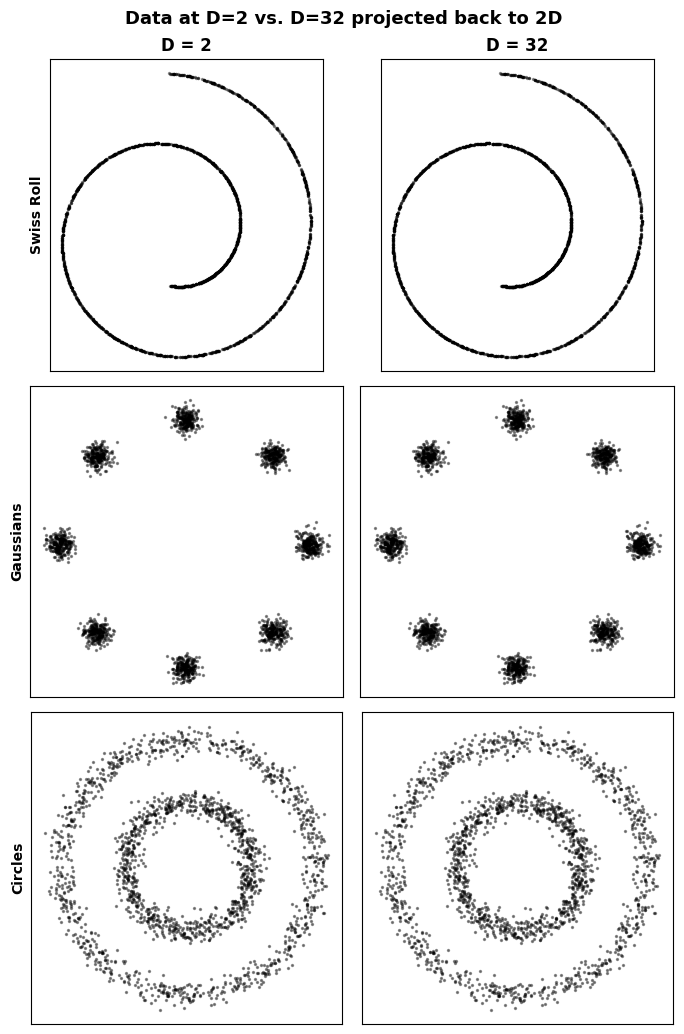

In [3]:
from src.dataloader import ToyDiffusionDataset

DATASETS = ["swiss_roll", "gaussians", "circles"]
N_SAMPLES = 2000

fig, axes = plt.subplots(len(DATASETS), 2, figsize=(7, 3.5 * len(DATASETS)))
fig.suptitle("Data at D=2 vs. D=32 projected back to 2D", fontsize=13, fontweight="bold")

for row, name in enumerate(DATASETS):
    for col, dim in enumerate([2, 32]):
        ds = ToyDiffusionDataset(name, dim=dim)
        pts = ds.to_2d(ds.data.numpy()[:N_SAMPLES])
        ax = axes[row, col]
        ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.4, c="black")
        ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(f"D = {dim}", fontweight="bold")
        if col == 0:
            ax.set_ylabel(name.replace("_", " ").title(), fontweight="bold")
plt.tight_layout()
plt.show()

Same spiral, same rings, same modes, at $D{=}2$ and projected back from $D{=}32$ —
confirming the orthogonal projection really does preserve the underlying 2D structure
regardless of ambient dimension.

**v-prediction sanity check at $D{=}2$.** Recommended hyperparameters: Adam, lr $10^{-3}$,
batch size 1024, 25,000 training steps, 50-step Euler sampling. Below is a **shortened live
demo** (3,000 steps, one dataset) using the real training code — just enough to watch it
converge in this notebook without a multi-minute wait; the reference figures loaded
afterward use the full 25K-step run on all three datasets.


  Training: v_pred_v_loss  (dim=2)
    step 500/3000  loss=0.990414
    step 1000/3000  loss=0.953224
    step 1500/3000  loss=0.985224
    step 2000/3000  loss=0.976043
    step 2500/3000  loss=0.959827
    step 3000/3000  loss=0.961288


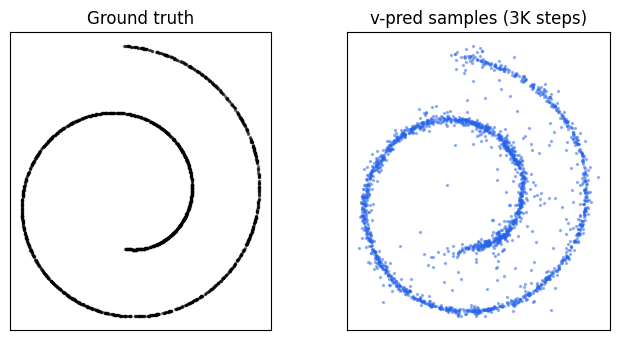

In [4]:
import torch
from src.diffusion import FlowMatching
from src.train import train_one

model, losses = train_one(pred_type="v", loss_type="v", dataset="swiss_roll", dim=2,
                           train_steps=3000, device="cpu")

flow = FlowMatching(sample_steps=50)
with torch.no_grad():
    samples = flow.sample(model, (N_SAMPLES, 2), "v", device="cpu").numpy()

gt = ToyDiffusionDataset("swiss_roll", dim=2).data.numpy()[:N_SAMPLES]
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].scatter(gt[:, 0], gt[:, 1], s=2, alpha=0.4, c="black"); axes[0].set_title("Ground truth")
axes[1].scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.4, c="#2563eb"); axes[1].set_title("v-pred samples (3K steps)")
for ax in axes:
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

Even at 3K steps (an 8th of the recommended budget) the spiral is already legible. Here's
the full 25K-step reference result on all three datasets (`part1_data.png`,
`part1_vpred.png` — reproduce via `uv run python scripts/plot_part0.py`):

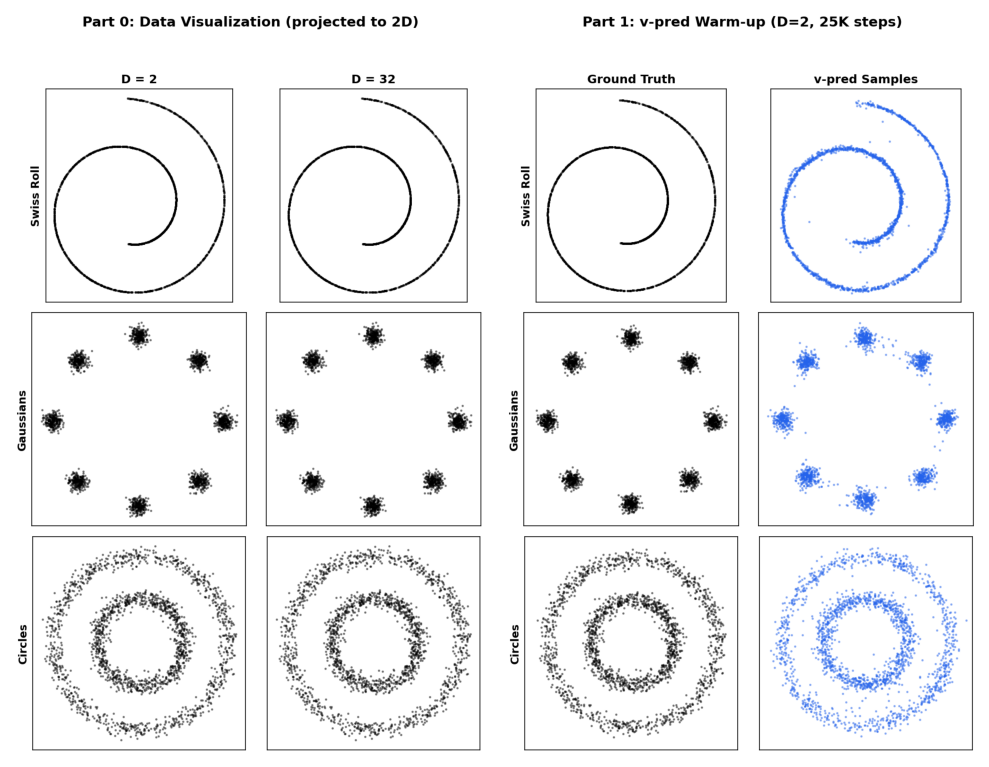

In [5]:
show_result("part1_data.png", "part1_vpred.png", figsize=(10, 10))

## Part 2: Flow Matching Parameterization

At $D{=}2$, everything works. The real question — the one this section is built around —
is what happens as the *ambient* dimension $D$ grows while the *intrinsic* dimension stays
fixed at 2, which is exactly the situation a real image/latent diffusion model is in.

**Parameterizations.** The model can predict two quantities (**pred_type**): $x$ (clean
data) or $v$ (velocity, $v = \epsilon - x$). The loss can be computed in either space
(**loss_type**), giving $2\times 2 = 4$ combinations. From $z_t = (1-t)x + t\epsilon$:

| from \\ to | $x$ | $v$ |
|---|---|---|
| **x-pred** | direct | $(z_t - \hat{x}) / t$ |
| **v-pred** | $z_t - t\hat{v}$ | direct |

Two of these conversions divide by $t$ or $(1-t)$ — singular as $t \to 0$ or $t \to 1$. The
reference implementation clips $t$ to $[T_{\text{eps}}, 1 - T_{\text{eps}}]$ to keep every
combination numerically finite; see the ablation table below for exactly how much that
matters.

**Sampling** always needs a *velocity* to step the ODE, regardless of what the model was
trained to predict directly — so x-pred and $\epsilon$-pred still convert to $v$ at every
sampling step, using the same table above.

In [7]:
# The real conversion + loss logic (src/diffusion.py) -- this is what actually ran to
# produce every result below, not a paraphrase:
print((TOY_FM_ROOT / "src" / "diffusion.py").read_text())

"""
Flow Matching.

Forward:  z_t = (1 - t) * x + t * eps,  t in [eps_t, 1 - eps_t]
          t=0 is data, t=1 is noise.
Loss:     any (pred_type, loss_type) pair with conversions.
Sampling: Euler ODE from t=1 (noise) to t=0 (data), 50 steps.
"""

import torch
import torch.nn.functional as F
from tqdm import tqdm

T_EPS = 1e-2


class FlowMatching:

    def __init__(self, sample_steps: int = 50):
        self.sample_steps = sample_steps

    def to(self, device):
        return self

    # ---- training loss -------------------------------------------------------

    def training_losses(self, model, x_0, pred_type, loss_type):
        B = x_0.shape[0]
        t = torch.rand((B, 1), device=x_0.device).clip(T_EPS, 1 - T_EPS)
        eps = torch.randn_like(x_0)
        xt = (1 - t) * x_0 + t * eps

        pred_raw = model(xt, t)

        # v = eps - x  (velocity from data toward noise)
        if loss_type == "v":
            if pred_type == "x":
                v_hat = (xt - pred_raw) 

**Running all 36 experiments** (2 pred types × 2 loss types × 3 dims × 3 datasets):

```bash
cd notebooks/toy_flow_matching
uv run python scripts/run_all.py --dataset swiss_roll
uv run python scripts/run_all.py --dataset gaussians
uv run python scripts/run_all.py --dataset circles
uv run python scripts/sample_and_visualize.py   # generates the figures below
```

Each figure: rows = x-pred / v-pred, columns = ground truth, $D{=}2$, $D{=}8$, $D{=}32$.

swiss_roll


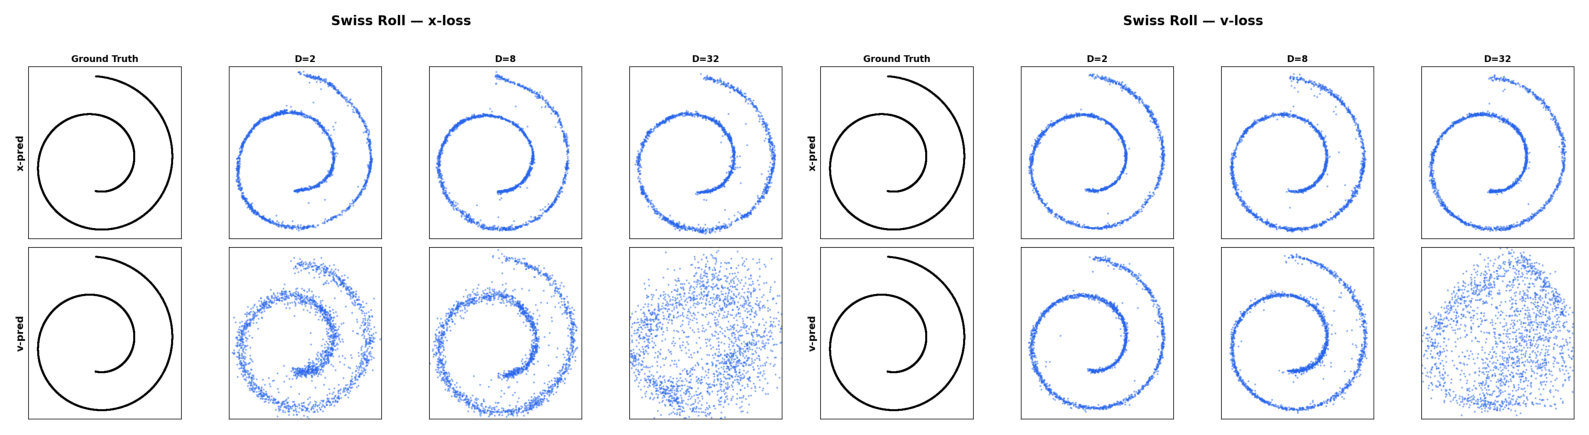

gaussians


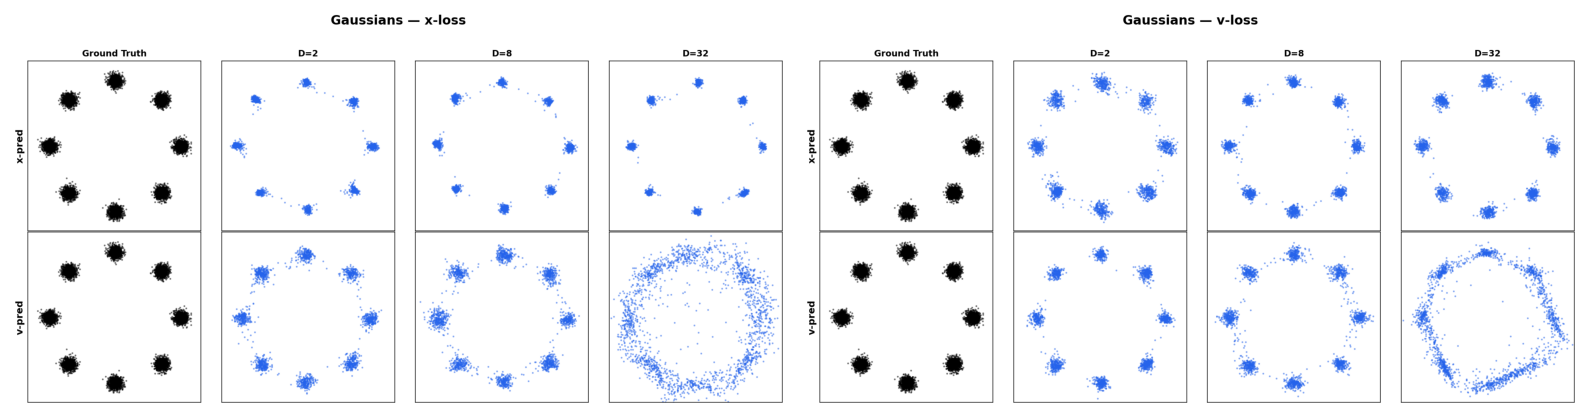

circles


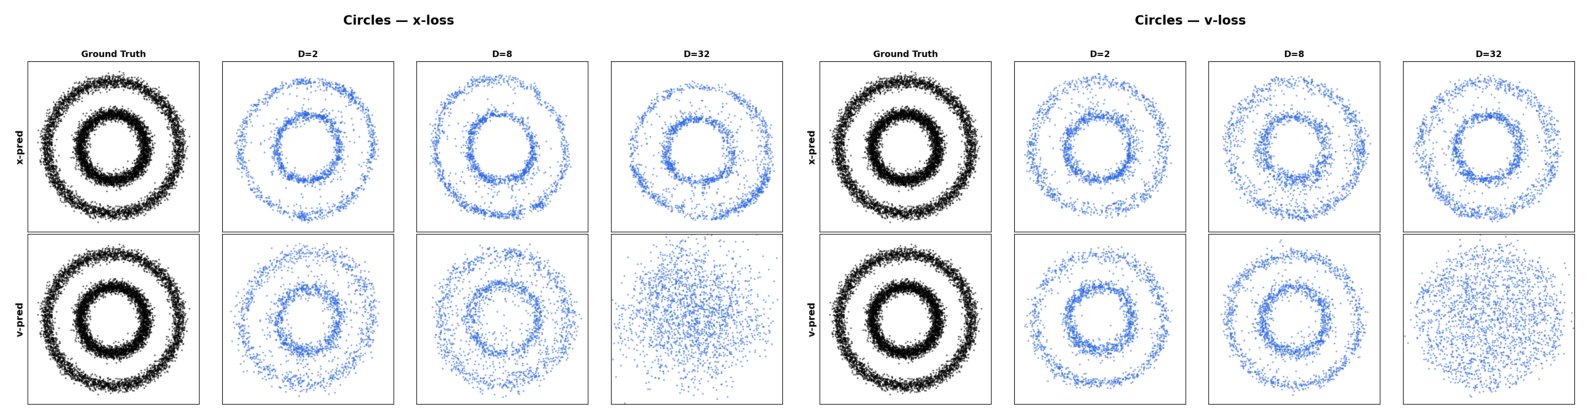

In [8]:
for ds in ["swiss_roll", "gaussians", "circles"]:
    print(ds)
    show_result(f"part2_{ds}_x_loss.png", f"part2_{ds}_v_loss.png", figsize=(16, 5))

**Training loss curves** (D=2 blue, D=8 green, D=32 red, overlaid per pred/loss combination):

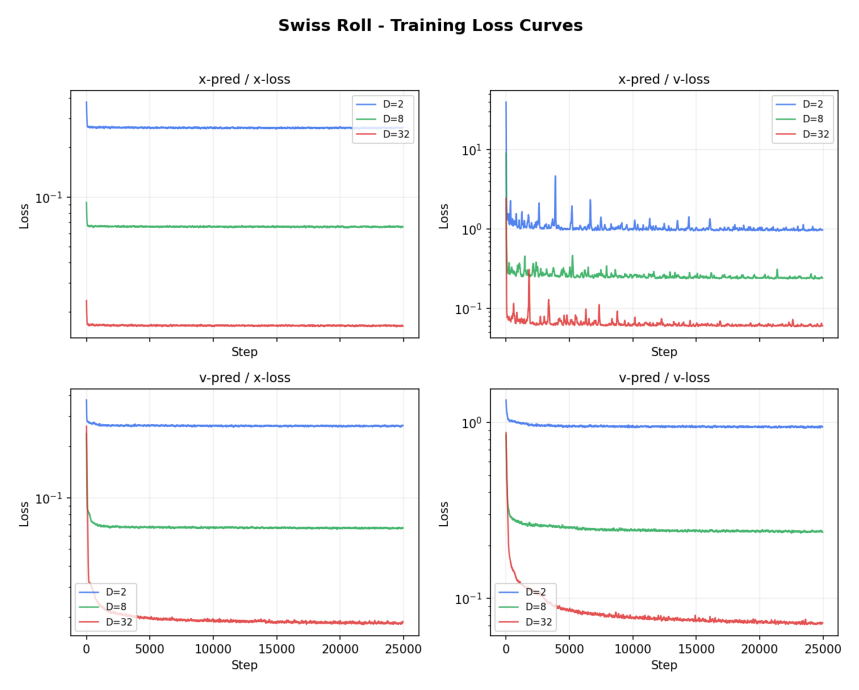

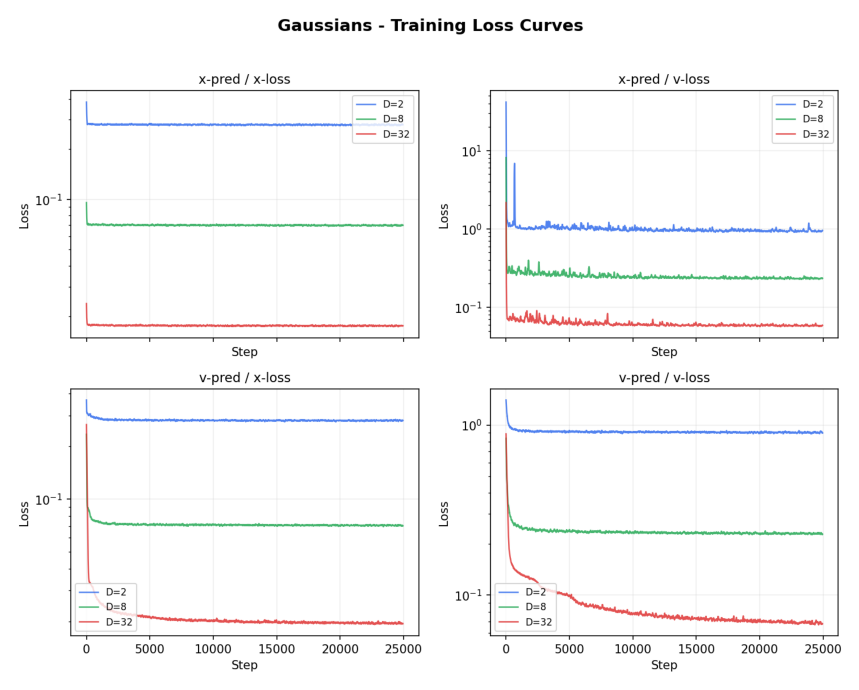

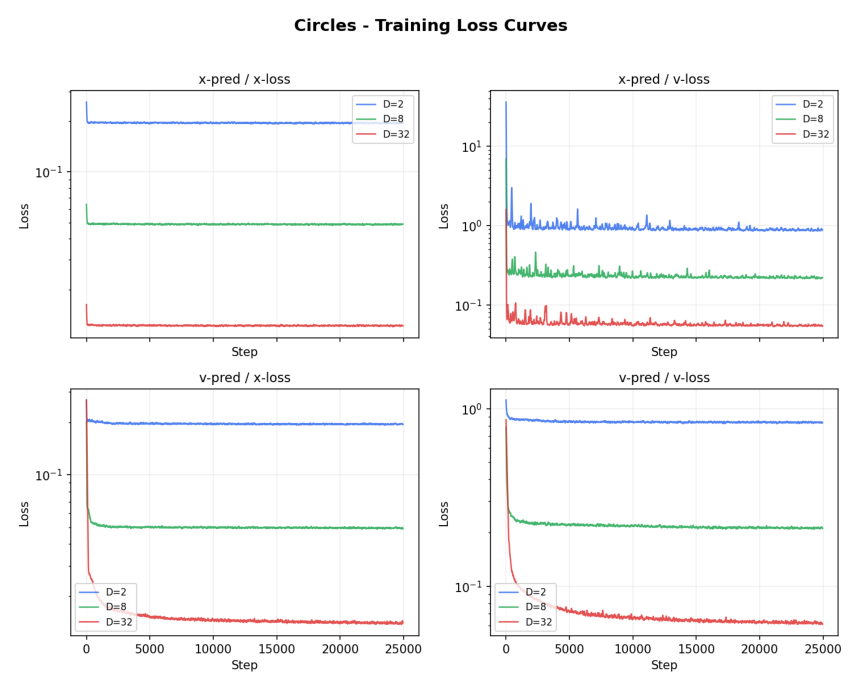

In [9]:
for ds in ["swiss_roll", "gaussians", "circles"]:
    show_result(f"part2_loss_curves_{ds}.png", figsize=(9, 7))

**Effect of timestep clipping** ($T_{\text{eps}}$), swiss_roll, $D{=}2$, 25K steps, final loss:

| $T_{\text{eps}}$ | x-pred/x-loss | x-pred/v-loss | v-pred/v-loss | v-pred/x-loss |
|---|---|---|---|---|
| 0     | 0.26 | **NaN** | 0.94 | 0.27 |
| 1e-5  | 0.28 | **357** | 0.88 | 0.26 |
| 1e-3  | 0.25 | **1.34** | 0.87 | 0.28 |
| 1e-2  | 0.26 | 0.96 | 1.00 | 0.25 |
| 5e-2  | 0.29 | 0.97 | 0.95 | 0.27 |

Without clipping, x-pred/v-loss diverges to NaN outright (it divides by $t$, which the
sampler pushes right up against $0$). $T_{\text{eps}}{=}10^{-2}$ is enough to stabilize every
combination. The *matched* combinations (x/x, v/v) don't move at all across this table —
they never divide by anything.

### Questions

**1. Which prediction type scales to high ambient dimension?** x-prediction produces
recognizable structure (spirals, modes, rings) at every $D$ tested, including $D{=}32$.
v-prediction visibly degrades at $D{=}32$: samples lose coherent structure and become
diffuse.

**2. Does the loss space (x-loss vs. v-loss) change which prediction type succeeds?** Only
marginally. x-prediction succeeds at all $D$ under both loss types; v-prediction fails at
high $D$ under both. The dominant factor is *what the model predicts*, not *what space the
gradient is computed in* — i.e. the failure is rooted in the prediction target itself, not
in the training signal's numerics. (Numerical instability in mismatched combinations like
x-pred/v-loss, from the $T_{\text{eps}}$ table above, is a separate implementation concern
from this parameterization question.)

**3. Why does x-prediction work at high $D$ while v-prediction doesn't?** *(Hint: think
about the rank of each target relative to $D$.)* The data lives on a 2D manifold embedded in
$D$-dimensional space. x-prediction asks the model to map noisy inputs back onto that
manifold — a rank-2 function no matter how large $D$ gets, so a small MLP suffices at any
$D$. v-prediction's target is $v = \epsilon - x$: since $\epsilon$ is full-rank
$D$-dimensional Gaussian noise, $v$ is dominated by the noise component and is effectively a
**rank-$D$** function. As $D$ grows, the model has to represent an increasingly complex
target with the same fixed capacity — and that's exactly where it starts to fail.

## Part 3: Can We Rescue v-Prediction?

From Part 2: x-prediction works with a 256-hidden-unit MLP at every $D$ tested; v-prediction
fails at $D{\geq}32$ with that same default setup. Is that failure fundamental, or can more
model capacity buy it back? (See RAE — *Representation Autoencoder* — Section 2, for the
underlying argument connecting parameterization and dimension.)

**Experiment.** Fix swiss_roll at $D{=}32$ (where v-pred starts failing) and sweep
`hidden_dim` $\in \{64, 128, 256, 512, 1024\}$ for v-prediction, with x-prediction at
`hidden_dim=256` as the fixed reference point:

```bash
uv run python scripts/run_vpred_scaleup.py --dataset swiss_roll
uv run python scripts/plot_scaleup.py
```

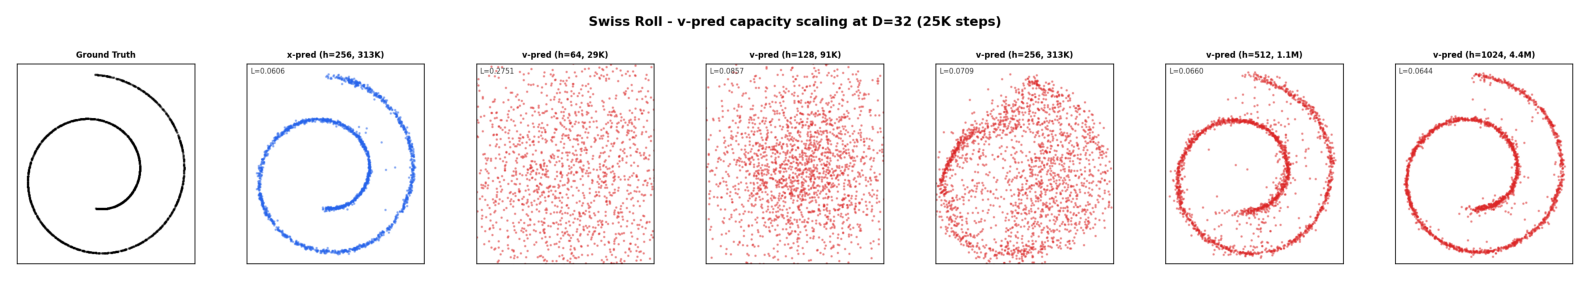

In [10]:
show_result("part3_scaleup_swiss_roll.png", figsize=(16, 3))

Final loss (v-loss, swiss_roll, $D{=}32$, 25K steps):

| hidden | params | v-pred loss | x-pred loss | ratio |
|---|---|---|---|---|
| 64   | 29K  | 0.275 | 0.064 | 4.3x |
| 128  | 91K  | 0.086 | 0.057 | 1.5x |
| **256**  | **313K** | **0.071** | **0.061** | **1.2x** |
| 512  | 1.1M | 0.066 | 0.057 | 1.2x |
| 1024 | 4.4M | **0.064** | 0.062 | **1.0x** |

x-prediction's loss stays flat around 0.06 regardless of model size — a rank-2 target that a
313K-parameter model already fully captures. v-prediction, by contrast, steadily improves
as capacity grows and only catches up to x-prediction's quality at `hidden_dim=1024` — a
**~14×** parameter increase (4.4M vs. 313K) just to match what x-prediction gets "for free."

### Questions

**1. Is v-prediction's failure fundamental?** No — it can be overcome, but only by paying a
real capacity cost. This confirms rather than contradicts the Part 2 rank argument: v-pred
needs a harder (rank-$D$) function approximated, so it needs more parameters to do it, not a
different mechanism.

**2. Compute cost vs. the x-prediction baseline?** At fixed 25K training steps,
x-prediction reaches loss ≈0.06 with 313K parameters; v-prediction needs ≈4.4M parameters
(hidden_dim 1024) to match it — roughly a **14× parameter** cost for equivalent quality.

**3. Do x- and v-prediction respond the same way to more capacity?** No. x-prediction's
loss plateaus immediately — more capacity doesn't help because the rank-2 target is already
fully captured at the smallest tested size. v-prediction improves monotonically with
capacity, consistent with needing to represent a genuinely harder, rank-$D$ target.

**4. Why does v-prediction work fine in real systems like Stable Diffusion 3 and FLUX?**
Real latent-diffusion models operate in a learned latent space where the *intrinsic*
dimension of natural images is a much larger fraction of the *ambient* dimension than in
these toy datasets (where intrinsic dimension is fixed at exactly 2, however large $D$
gets). When that ratio is reasonable, v-prediction doesn't pay the same capacity penalty,
and its other properties — e.g. more balanced gradients across timesteps — become a net
advantage rather than a liability.

## Part 4: One-Step Generation with MeanFlow

Parts 1-3 all used 50-step Euler ODE integration to sample. As step count drops, quality
degrades — at 1 step, the ODE simply can't traverse the full noise-to-data path in one
straight-line jump. **MeanFlow** ([Sun et al., 2025](https://arxiv.org/abs/2505.13447))
targets the *average* velocity over an interval $[r, t]$ rather than the instantaneous
velocity at a single $t$. The model $u(z, t, h)$ takes an extra input $h = t - r$ (the
horizon): at $h{=}0$ it reduces to standard instantaneous-velocity flow matching; at
$h{=}1$ (spanning the whole $[0,1]$ path) a *single* application of $u$ is enough to jump
straight from noise to data.

Training uses a JVP (Jacobian-vector product, via `torch.func.jvp`) to compute a
self-consistent target — the real training step, from `src/diffusion_mf.py`:

```python
def u_fn(z, t_in, r_in):
    x_pred = model(z, t_in, t_in - r_in)          # model still predicts x -- see below
    return (z - x_pred) / t_in.clip(min=T_CLIP_MIN) # converted to velocity u

(u, du_dt) = torch.func.jvp(u_fn, (z_t, t, r), (v, ones_like(t), zeros_like(r)))
u_tgt = (v - (t - r) * du_dt).detach()             # self-consistency target
loss = MSE(u, u_tgt)                                # (with per-sample adaptive weighting)
```

Half of training uses $h{=}0$ (`fm_ratio=0.5`) — plain flow matching — and half uses
$h{>}0$ (mean velocity). MeanFlow **predicts $x$, not $v$** — directly following the Part 2/3
finding that x-prediction is the only parameterization that scales cleanly with $D$, and
this is trained at $D{=}32$.

```bash
uv run python src/train_mf.py --train-steps 25000
uv run python scripts/run_sampling_steps.py    # left figure below
uv run python scripts/plot_meanflow.py         # right figure below
```

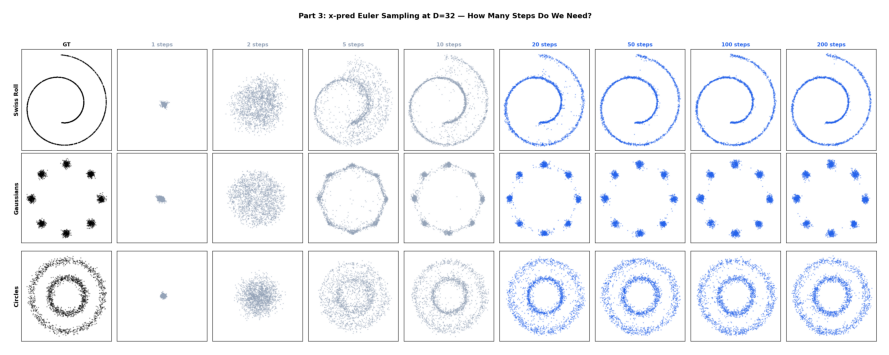

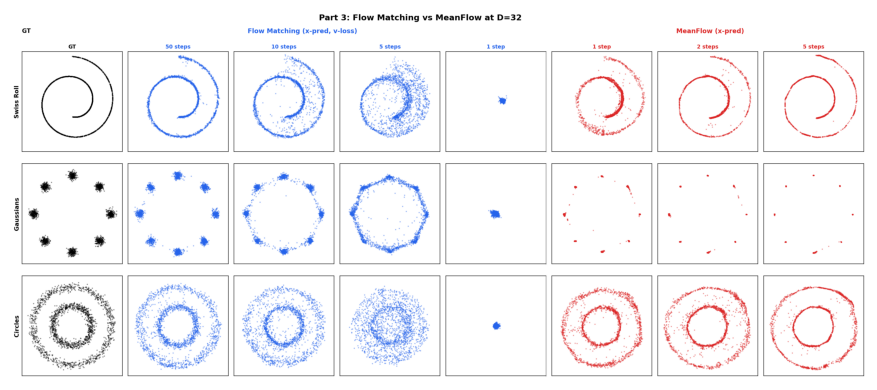

In [11]:
show_result("part4_sampling_steps.png", figsize=(9, 4))
show_result("part4_meanflow.png", figsize=(9, 4))

**Left:** x-prediction quality degrades quickly as Euler steps drop; at 1 step, the output
collapses to a concentrated blob — standard flow matching fundamentally needs multiple
steps. **Right (blue):** rectified flow at 50/10/5/1 Euler steps. **(red):** MeanFlow at
1/2/5 steps. Even at a single step, MeanFlow already shows recognizable structure; by 5
steps it approaches the 50-step flow-matching baseline.

### Questions

**1. Why x-prediction for MeanFlow?** Direct consequence of Part 2: v-prediction fails to
scale to $D{=}32$ regardless of the sampling method used on top of it, so building MeanFlow
on x-prediction sidesteps that failure mode entirely.

**2. Core idea, in short.** Standard flow matching learns the instantaneous velocity at one
$t$, so generation needs many small integration steps. MeanFlow instead learns the *average*
velocity over an interval $[r, t]$; when that interval spans the whole path ($r{=}0, t{=}1$),
a single step using the mean velocity carries a sample all the way from noise to data.

**3. Why is the $h{=}0$ portion of training needed?** It's the grounding signal: mean
velocity over $[r,t]$ is *defined* in terms of the instantaneous velocity field, so without
$h{=}0$ training the model has no anchor for what that field looks like at any point at all.
$h{=}0$ teaches a valid velocity field; $h{>}0$ then teaches the model to integrate over
progressively longer intervals of it.

**4. Training cost vs. standard flow matching.** Similar step counts (~25K), but each step
costs roughly 2× as much — the JVP needs both a forward pass and a tangent-linear pass
through the model. The optimization is also just harder: the model must give consistent
velocity predictions across *every* horizon length simultaneously, not just at one $t$.

**5. Artifacts, particularly on `gaussians`?** On swiss_roll and circles, 1-step MeanFlow
gives recognizable (if slightly noisy) structure, closing in on the 50-step baseline by 5
steps. On `gaussians`, 1-step MeanFlow shows a distinct failure mode: points cluster tightly
at the mode centers with far less spread than ground truth. The MSE objective pushes the
model toward $\mathbb{E}[x \mid z_t]$ — when a noise sample sits roughly equidistant between
two modes, the model predicts their *average*, and at 1 step there's no room for the
trajectory to diverge toward one mode or the other the way a multi-step trajectory can.

---

That's the parameterization question that motivates a real design choice in the pipeline
below: the dog-breed DiT operates on a 32-channel × 16×16 VAE latent (ambient dimension
8192) whose intrinsic dimension is far higher than the toy datasets' fixed 2 — exactly the
regime where Part 3's Question 4 said v-prediction should be fine. That's why the configs
you'll see from here on all set `transport.prediction: 'velocity'`.

From here, the rest of this notebook builds the real pipeline: a real VAE tokenizer, a real
text encoder, a real 12-block DiT, trained end-to-end on real dog photos.

---

# Task 2: Training a text-to-image DiT end to end

Task 1 settled the parameterization on toy data. Task 2 builds the real thing: data pipeline,
frozen components, DiT backbone, pretraining, fine-tuning, and three kinds of evaluation.

Sections 0-7 set up and explain each piece. Sections 8-11 run the two experiments and score them.
Every command calls into the diffusion-bench repo, so the notebook stays a guide and the repo stays
the single source of truth for the code.

## 0. Setup & configuration

Clone the repo and install dependencies:

```bash
git clone https://github.com/Reyhaneesmailizadeh/diffusion-bench.git
cd diffusion-bench
curl -LsSf https://astral.sh/uv/install.sh | sh   # install uv, if you don't have it
uv sync                                            # reproduces the exact Python environment
```

Every path below is a placeholder pointing at *your own* working directory — nothing here
resolves to any pre-existing data or checkpoints. Fill these in once and every later cell in
this notebook reuses them, and every shell command in this notebook uses the equivalent
`$DOGS_ROOT`-style variable so you can copy-paste them directly into a terminal too.


In [ ]:
from pathlib import Path

# REPO_ROOT is found automatically: this notebook lives inside the repo, so walk up
# from the working directory until the marker file appears. Nothing to edit here.
def _repo_root(start=None):
    here = Path(start or Path.cwd()).resolve()
    for d in [here, *here.parents]:
        if (d / "src" / "train.py").exists() and (d / "configs").is_dir():
            return d
    raise FileNotFoundError(
        "Could not locate the diffusion-bench root above " + str(here) + ". Run this "
        "notebook from inside a clone of the repo.")

REPO_ROOT = _repo_root()

# These two DO need editing: they are your own data and checkpoint locations, and
# should sit on a disk with room (the latent caches run to tens of GB).
DOGS_ROOT = Path("/path/to/your/data/dogs")   # <-- all dog data + precomputed caches
CKPT_ROOT = REPO_ROOT / "ckpts"               # <-- trained checkpoints (repo default)

# Sub-paths used throughout the notebook -- populated as you work through Section 7.
RECAPTIONED_WDS_DIR  = DOGS_ROOT / "dogs_recaptioned_wds"          # downloaded in Section 7.1
PRETRAIN_LATENTS_DIR = DOGS_ROOT / "dogs_recaptioned_latents_wds"  # after scripts/precompute_latents.py

SFT_WDS_DIR      = DOGS_ROOT / "dogs_sft_wds"                      # downloaded in Section 7.1
SFT_LATENTS_DIR  = DOGS_ROOT / "dogs_sft_latents_wds"

print(f"REPO_ROOT  {REPO_ROOT}  (auto-detected)")
for name, p in [("DOGS_ROOT", DOGS_ROOT), ("CKPT_ROOT", CKPT_ROOT)]:
    print(f"{name}  {p}  {'(exists)' if p.exists() else '<-- point this somewhere real before Section 7'}")

## 1. Pipeline overview

```
raw images + captions                 (jpg + txt pairs, WebDataset shards)
        │
        │  scripts/precompute_latents.py   (Section 7)
        ▼
precomputed cache: VAE latents + text embeddings + DINOv2 features, per sample
        │
        │  Stage-2 training (flow matching + REPA loss)          (Sections 5-6)
        ▼
Experiment 1: pretrain LightningDiT from scratch, 200 epochs      (Section 8)
        │
        │  warm-start from the pretrained checkpoint, fine-tune on
        │  a smaller domain-specific dataset
        ▼
Experiment 2: SFT on dogs-synthetic-2k, 100 epochs                (Section 9)
        │
        ▼
inference: generate images from text captions, evaluate FID/IS    (Section 10)
```

**Why two stages (VAE + DiT) instead of one model working directly on pixels?** A 256×256
RGB image is 196,608 numbers. Running a transformer directly over that many positions is
prohibitively expensive. A VAE (Stage 1, described in Section 2) is trained once to compress
an image into a much smaller *latent* grid — here, 16×16×32 — that still contains enough
information to reconstruct a visually near-identical image. The DiT (Stage 2) then only has
to learn to generate 16×16=256 latent tokens instead of 196,608 pixels, which is what makes
training a transformer-based image generator tractable at all. This is the same idea behind
Stable Diffusion and most modern latent diffusion models.

**Why two *training* stages (pretrain + SFT)?** The pretrained model learns general
"what a dog looks like, and how to follow a caption" from a large, broad dataset. The
SFT stage then specializes that general ability onto a smaller, cleaner, more specifically
curated dataset (20 hand-picked breeds, synthetic images). This is the same
pretrain-then-fine-tune pattern used throughout modern deep learning (e.g. LLM pretraining
+ instruction tuning) — and, as Section 9 shows with real data, it comes with a real gotcha:
your evaluation metric can move in a direction that looks bad but isn't, if the fine-tuning
set has a different image distribution than whatever your metric is comparing against.


## 2. Model component: the visual tokenizer (Stage 1 VAE)

The VAE (`src/stage1/vae.py`) is a **frozen**, pretrained autoencoder — it is never trained
as part of this project, only used to encode images into latents and decode latents back
into images. It wraps a HuggingFace `diffusers.AutoencoderKL` checkpoint. The specific
variant used throughout, `e2e-invae`, resolves to the pretrained weights
`REPA-E/e2e-invae-hf` (`VAE_CONFIGS` in `vae.py`) — a VAE whose latent space was itself
trained end-to-end with a REPA-style alignment objective against a self-supervised vision
encoder, which is a separate, unrelated-to-us detail of how *that* checkpoint was produced;
we just consume it as a fixed component.

Key numbers: 32 latent channels, 16× spatial downsampling — so a 256×256×3 image becomes a
16×16×32 latent (which is exactly `misc.latent_size: [32, 16, 16]` in the stage-2 configs).

**Why this specific tokenizer?** The choice of visual tokenizer is not incidental to the
headline result at the top of this notebook — it's one of the main knobs that was varied
during the two months of comparisons that produced this recipe. A tokenizer's latent
channel count and spatial downsampling ratio directly set how many tokens the DiT has to
learn to generate (here, 16×16=256), which is a first-order driver of how much compute a
given FID target costs to reach. `e2e-invae` was the compressor that came out of that
comparison as the best fit for training a small DiT quickly; the tokenizer is swappable
(see `VAE_CONFIGS` in `vae.py`) if you want to reproduce that comparison yourself.

Exact source, `src/stage1/vae.py`:

```python
@torch.no_grad()
def encode(self, x: torch.Tensor) -> torch.Tensor:
    x = self._preprocess(x)
    posterior = self._vae_encode(x)
    z = posterior.sample() if self.sample_mode == "sample" else posterior.mode()
    z = (z - self.shift_factor) * self.scaling_factor
    return z

def decode(self, z: torch.Tensor) -> torch.Tensor:
    z = z / self.scaling_factor + self.shift_factor
    x = self._vae_decode(z)
    return ((x + 1.0) / 2.0).clamp(0, 1)  # [-1, 1] -> [0, 1]
```

Let's actually load it and see it work.


In [ ]:
import sys
sys.path.insert(0, str(REPO_ROOT / "src"))

import torch
from torchvision.utils import make_grid
from torchvision.transforms.functional import to_pil_image

from utils.model_utils import instantiate_from_config
from omegaconf import OmegaConf

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

stage1_cfg = OmegaConf.create({
    "target": "stage1.VAE",
    "params": {"vae_type": "e2e-invae", "resolution": 256},
})
rae = instantiate_from_config(stage1_cfg).to(device).eval()
print(f"Stage-1 VAE loaded. Latent channels: {rae.latent_dim}, downsample factor: {rae.patch_size}")


In [ ]:
# Encode one of your own images and decode it straight back, to see how much visual
# information survives the 256x256x3 -> 16x16x32 compression. Pulls a single sample
# straight out of a WebDataset shard -- run Section 7.1 first so $RECAPTIONED_WDS_DIR
# actually has shards in it, or point shard_path at any other .tar you already have.
import io
import tarfile
from PIL import Image
from torchvision import transforms

shard_path = next(RECAPTIONED_WDS_DIR.glob("*.tar"))  # <-- or set this to a specific shard
with tarfile.open(shard_path) as tf:
    jpg_member = next(m for m in tf.getmembers() if m.name.endswith(".jpg"))
    img = Image.open(io.BytesIO(tf.extractfile(jpg_member).read())).convert("RGB")
print(f"using: {shard_path.name} :: {jpg_member.name}")

transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(256),
    transforms.ToTensor(),  # [0, 1]
])
x = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    z = rae.encode(x)
    x_rec = rae.decode(z)

print(f"image shape: {tuple(x.shape)}  ->  latent shape: {tuple(z.shape)}  ->  reconstructed: {tuple(x_rec.shape)}")
print(f"compression ratio: {x.numel() / z.numel():.1f}x fewer numbers in latent space")

grid = make_grid(torch.cat([x, x_rec], dim=0), nrow=2)
to_pil_image(grid.cpu())


## 3. Model component: text conditioning (Qwen3-0.6B)

Captions are encoded with **Qwen3-0.6B** (`conditioning.text_encoder.model_name` in the
configs), a small language model, used purely as a text encoder here (not for generation).
Two choices worth calling out because they differ from common practice (e.g. plain CLIP text
encoders):

- **Per-token, not pooled.** The model keeps *all* token hidden states
  (`max_length: 128` tokens), not a single pooled embedding. This gives the DiT much more
  granular conditioning information to attend to — which specific word corresponds to which
  part of the image can, in principle, be resolved token-by-token rather than being
  collapsed into one vector up front.
- **A causal LLM as a text encoder** rather than a model trained specifically for
  cross-modal alignment (like CLIP) — the hidden states it produces are optimized for
  language modeling, not for being "reachable" from images. Whether this matters much in
  practice is exactly the kind of question this pipeline's REPA and attention-alignment
  experiments try to probe.

**Classifier-free guidance (CFG).** During training, `conditioning.cfg_dropout_prob: 0.1` replaces
the caption with a null embedding on 10% of samples, so the same network learns both the
caption-conditioned and unconditioned velocity fields. At sampling time the two are combined,

$$v = v_{\text{uncond}} + s \cdot (v_{\text{cond}} - v_{\text{uncond}}),$$

with the guidance scale $s$ set by `guidance.cfg.scale` (6.0 in these configs). Larger $s$ pushes
samples harder toward the caption at some cost to diversity. This is why the config carries both a
dropout probability at train time and a scale at sample time; they are two halves of one mechanism.

In [ ]:
from stage2.utils import setup_text_encoder
from configs.stage2 import Stage2Config, ConditioningConfig, TextEncoderConfig

text_cfg = Stage2Config()
text_cfg.conditioning = ConditioningConfig(
    type="text",
    text_encoder=TextEncoderConfig(model_name="Qwen/Qwen3-0.6B", max_length=128),
)
text_encoder = setup_text_encoder(text_cfg, rank=0, device=device)

caption = "Afghan Hound, adult, slender build, long silky golden coat, standing in a grassy field."
with torch.no_grad():
    enc_out = text_encoder([caption])

print(f"tokens shape: {tuple(enc_out['tokens'].shape)}   (batch, seq_len=128, hidden_dim)")
print(f"attention_mask shape: {tuple(enc_out['attention_mask'].shape)}")
print(f"real (non-padding) tokens in this caption: {int(enc_out['attention_mask'].sum())}")


## 4. Model component: REPA (representation alignment)

**The idea.** DINOv2 (Oquab et al., 2023) is a self-supervised vision transformer whose
learned features are known to be strongly, cleanly semantic — similar objects/parts end up
with similar features, without ever being trained for a specific downstream task. REPA
(Yu et al., "Representation Alignment for Generation," 2024) observed that diffusion
transformers train noticeably faster and generate better images if you add an auxiliary loss
pulling one of the DiT's *own intermediate hidden states* toward DINOv2's features of the
*clean* target image — effectively giving the DiT's early/middle layers a semantic "head
start" it would otherwise have to discover purely from the denoising objective.

**In this codebase**, `Transport.training_losses` (`src/stage2/transport/transport.py`) calls
the DiT with `return_intermediate=True`, which makes it also return `zt_pred` — its own
hidden state at layer `repa_layer_depth`, projected to DINOv2's feature dimension via a small
linear head (`self.repa_projector` in `LightningDiT`). The loss itself is the exact source:

```python
loss_repa = th.tensor(0.0, device=x1.device)
if enable_repa and zt_pred is not None:
    loss_repa = repa_coeff * F.mse_loss(zt_pred, z_clean)
terms['loss_repa'] = loss_repa
```

`z_clean` is DINOv2's real patch-token features of the *clean* target image, computed once
and cached during Section 7's precompute step, not recomputed live during training.

Both pretraining and SFT configs here use `repa_layer_depth: 4` (align at the 4th of 12
DiT layers) and `repa_coeff: 0.5` (weight of this auxiliary loss relative to the main
denoising loss), with `target_encoder: dinov2-vit-bnormworeg`.


## 5. Model component: LightningDiT — the generative backbone

This is the actual transformer being trained. Standard DiT ingredients: patchify the latent
into a sequence of tokens (here `patch_size: 1`, so each of the 16×16 latent's spatial
positions is already one token — 256 image tokens total), run them through transformer
blocks, unpatchify the output back into a latent-shaped velocity prediction.

**The one big architectural choice worth dwelling on: how is the model conditioned on time
and text?** The original DiT paper (Peebles & Xie, 2022) uses *AdaLN-Zero*: a small MLP
predicts per-block scale/shift/gate values from the conditioning vector, and every
LayerNorm in the network is modulated by those values. **This codebase does not do that.**
Instead it uses **in-context conditioning**: the time embedding and the (per-token!) text
embedding are turned into extra *tokens* and literally concatenated onto the sequence of
image tokens:

Exact source, `src/stage2/models/lightningDiT.py` (`enable_reg` and `use_cfg_conds` are both
`False` in every config used in this notebook, so in practice this reduces to image tokens +
time tokens + text tokens, concatenated in that order):

```python
def _build_sequence(self, x, t, condition_kwargs):
    seq = []
    if self.enable_reg:
        seq.append(self.cls_in_norm(self.cls_in_proj(condition_kwargs["cls_t"])).unsqueeze(1))
    seq.append(self.x_embedder(x))
    seq.append(self.t_embedder(t))
    if self.use_cfg_conds:
        seq.append(self.cfg_w_embedder(condition_kwargs["omega"]))
    seq.append(self.ctx_embedder(condition_kwargs["context"]))
    seq = torch.cat(seq, dim=1)
    return seq
```

The whole concatenated sequence then goes through **plain, unconditional** RMSNorm and
**joint self-attention** — every block's attention is one shared softmax over image, time,
*and* text tokens together, with no separate cross-attention module and no per-block
modulation. This has a nice side effect: because time and text genuinely occupy real
sequence positions, you can directly slice out "how much does image token $i$ attend to text
token $j$" as a literal sub-block of the attention matrix — which is exactly the mechanism
the attention-alignment side-experiment (not covered in depth in this notebook) is built on.

Other implementation details, each a small deliberate choice:
- **RMSNorm**, not LayerNorm (fewer parameters, no mean-subtraction, standard in recent
  LLM/DiT work).
- **2D RoPE** (rotary position embeddings) for the image tokens only — time and text tokens
  get a zero rotation angle, i.e. no positional bias, since "position in the caption" isn't
  meaningful the way "position in the image grid" is.
- **QK-norm**: an RMSNorm applied to queries and keys before the attention dot-product, a
  common stabilization trick.
- **SwiGLU**, not a plain ReLU/GELU MLP, for the feed-forward blocks.


In [ ]:
from stage2.models.lightningDiT import LightningDiT
from configs.stage2 import ConditioningArchConfig

# A small instance, just to inspect shapes and count parameters -- the real pretraining
# config uses hidden_size=1152, depth=28 (much larger); this cell is about the mechanism,
# not about training a usable model.
cond_arch = ConditioningArchConfig(num_t_tokens=4, num_c_tokens=128)
toy_dit = LightningDiT(
    input_size=16, patch_size=1, in_channels=32, hidden_size=384, depth=12, num_heads=6,
    condition_type="text", context_dim=1024, cond_arch=cond_arch,
).to(device)

n_params = sum(p.numel() for p in toy_dit.parameters())
print(f"Params: {n_params / 1e6:.1f}M   Image tokens: {toy_dit.x_embedder.num_patches}")

B = 2
x = torch.randn(B, 32, 16, 16, device=device)
t = torch.rand(B, device=device)
context = torch.randn(B, 128, 1024, device=device)
attn_mask = torch.ones(B, 128, device=device)

with torch.no_grad():
    v_pred = toy_dit(x, t, context=context, attn_mask=attn_mask)
print(f"input latent: {tuple(x.shape)}  ->  predicted velocity: {tuple(v_pred.shape)}  (same shape, as expected)")


## 6. Putting it together: the full training loss

Task 1 established the flow-matching objective on toy data. Here is the same objective as the
codebase actually implements it, plus the REPA term from Section 4.

Every training step, per micro-batch:

$$\mathcal{L} = \underbrace{\| v_\theta(x_t, t, \text{caption}) - v_t \|^2}_{\text{flow-matching loss}} \;+\; \lambda_{\text{repa}} \underbrace{\| \text{proj}(h_4) - f_{\text{DINOv2}}(x_1) \|^2}_{\text{REPA loss (Sec. 4)}}$$

where $h_4$ is the DiT's own hidden state at layer 4. The noisy latent and the velocity target
are built in `Transport.sample` and `Transport.training_losses`
(`src/stage2/transport/transport.py`), with $x_1$ the clean VAE latent and $x_0$ Gaussian noise:

```python
xt = (1 - t) * x1 + t * x0                     # straight-line path, t=0 data, t=1 noise
vt = (xt - x1) / t.clamp_min(self.t_eps)       # velocity target, equals x0 - x1
...
loss = (model_output - vt) ** 2                # flow-matching term
loss_repa = repa_coeff * F.mse_loss(zt_pred, z_clean)   # REPA term
```

Both terms are summed before a single `backward()` call, so gradients from the REPA term flow
back through the same network, all the way to the embedders, alongside the denoising gradient.

## 7. Data pipeline: get the data and precompute

Both datasets used in this notebook — the 26k-image pretraining set and the 2k-image SFT
set — are provided as ready-to-use WebDataset shards. This section gets you from those raw
shards to the precomputed latents caches (`PRETRAIN_LATENTS_DIR`, `SFT_LATENTS_DIR`) that
Sections 8 and 9 train from.

### 7.1 Download the raw WebDataset shards

Both datasets are hosted on the Hugging Face Hub, alongside the 500-caption evaluation set
used in Sections 10-11:
[`reyhanehesi/dog-t2i-diffusion-data`](https://huggingface.co/datasets/reyhanehesi/dog-t2i-diffusion-data).

> This repo is **private** while the paper is under review and will be made public alongside
> publication. Until then, request access from the author, then run `hf auth login` with
> your own token before the cell below.

```bash
mkdir -p $RECAPTIONED_WDS_DIR $SFT_WDS_DIR

uv run hf download reyhanehesi/dog-t2i-diffusion-data dogs_recaptioned_wds.tar.gz \
    --repo-type dataset --local-dir /tmp
tar -xzf /tmp/dogs_recaptioned_wds.tar.gz -C $RECAPTIONED_WDS_DIR

uv run hf download reyhanehesi/dog-t2i-diffusion-data dogs_synthetic_2k_wds.tar.gz \
    --repo-type dataset --local-dir /tmp
tar -xzf /tmp/dogs_synthetic_2k_wds.tar.gz -C $SFT_WDS_DIR
```

Each is a plain WebDataset — `.tar` shards where every sample is a `{key}.jpg` + `{key}.txt`
pair:

```bash
$ tar -tf $RECAPTIONED_WDS_DIR/shard-00000.tar | head -4
afghan_hound/n02088094_10.jpg
afghan_hound/n02088094_10.txt
afghan_hound/n02088094_1003.jpg
afghan_hound/n02088094_1003.txt
```

### 7.2 Precompute latents

**Why precompute latents offline instead of running the VAE/text-encoder/DINOv2 forward
passes every training step?** Those three models are frozen — their outputs for a given
image+caption never change during stage-2 training. Recomputing them on every single epoch
is pure wasted compute (three extra forward passes per sample, every epoch, for the entire
training run). `scripts/precompute_latents.py` runs each frozen model **once** over the
whole dataset and caches the results — VAE latent, per-token text embedding, attention
mask, and DINOv2 patch features — into new WebDataset shards. Stage-2 training then just
reads these cached tensors directly, no frozen-model forward passes needed at train time at
all.

Run it once per dataset — pretraining:

```bash
uv run torchrun --nproc_per_node=4 scripts/precompute_latents.py \
    --config configs/stage2/training/t2i/t2i-ddt-en28d1152hd72-dn2d2048hd128-e2e-invae-vpred-t4-RePA-latents-EMA0.9995.yaml \
    --input-dir $RECAPTIONED_WDS_DIR \
    --output-dir $PRETRAIN_LATENTS_DIR \
    --batch-size 16
```

and SFT:

```bash
uv run torchrun --nproc_per_node=4 scripts/precompute_latents.py \
    --config configs/stage2/training/t2i/t2i-ddt-en28d1152hd72-dn2d2048hd128-e2e-invae-vpred-t4-RePA-latents-SFT-dogs-synthetic-EMA0.995.yaml \
    --input-dir $SFT_WDS_DIR \
    --output-dir $SFT_LATENTS_DIR \
    --batch-size 16
```

At train time, `DogsLatentsWebDataset` (`src/data/dogs_latents_wds_dataset.py`) reads these
shards directly — `dataset.type: 'latents'` in the configs selects this path instead of
decoding raw images. Point each config's `dataset.data_dir` at the matching latents
directory (`$PRETRAIN_LATENTS_DIR` for Section 8, `$SFT_LATENTS_DIR` for Section 9) before
moving on.


## 8. Experiment 1: pretraining LightningDiT from scratch

Config:
`configs/stage2/training/t2i/t2i-ddt-en28d1152hd72-dn2d2048hd128-e2e-invae-vpred-t4-RePA-latents-EMA0.9995.yaml`

Key settings, and *why*:

| Setting | Value | Why |
|---|---|---|
| `training.epochs` | 200 | full pretraining budget |
| `training.global_batch_size` | 256 | split across 4 GPUs |
| `training.ema_decay` | 0.9995 | slow-moving EMA of weights, used for sampling/eval — smooths out training noise |
| `optimizer.lr` / `scheduler.base_lr` | 1e-4 | `scheduler.base_lr` is the one that actually takes effect (it overwrites the optimizer's LR right after construction) — keep both in sync in the config to avoid confusion |
| `scheduler.warmup_epochs` | 100 | long warmup, appropriate for training a large model from scratch |
| `scheduler.final_lr` | 1e-5 | linear decay target — LR ends at 1/10th of `base_lr` by the end of the schedule |
| `repa.use_repa` | true | Section 4 |

```bash
export EXPERIMENT_NAME=dit-pretrain-run-1     # <-- name your own run
export ENTITY=your-wandb-entity
export PROJECT=dogs-lightningdit

CUDA_VISIBLE_DEVICES=0,1,2,3 uv run torchrun --standalone --nproc_per_node=4 \
    src/train.py \
    --config configs/stage2/training/t2i/t2i-ddt-en28d1152hd72-dn2d2048hd128-e2e-invae-vpred-t4-RePA-latents-EMA0.9995.yaml \
    --precision bf16 \
    --wandb
```

This writes checkpoints to `ckpts/$EXPERIMENT_NAME/checkpoints/ep-XXXXXXX.pt` — the epoch
you pick from your own run is what feeds into Section 9. On 4x RTX 3090s the full 200-epoch schedule takes about 2h15m, of which roughly 45 minutes is
the four periodic FID/IS evaluations rather than training. Expect proportionally longer on
fewer or smaller GPUs. Watch the loss and REPA-loss curves in
Weights & Biases while it runs.

### Which configuration to run, and why this one

The config above was picked by running the whole 200-epoch schedule under all eight combinations
of three choices: which tokenizer (E2E-INVAE vs E2E-VAVAE), whether the REPA loss is on, and
whether captions are encoded with a 64- or 128-token budget. All eight configs ship with the repo,
so any of them can be run with the same command by swapping `--config`:

| Tokenizer | REPA | Tokens | Config file (under `configs/stage2/training/t2i/`) | Final FID |
|---|:--:|:--:|---|--:|
| **E2E-INVAE** | **yes** | **128** | **`...-e2e-invae-vpred-t4-RePA-latents-EMA0.9995.yaml`** | **9.4** |
| E2E-INVAE | yes | 64 | `...-e2e-invae-vpred-t4-RePA-latents-64tok-EMA0.9995.yaml` | 9.8 |
| E2E-INVAE | no | 128 | `...-e2e-invae-vpred-t4-NORePA-latents-EMA0.9995.yaml` | 11.5 |
| E2E-INVAE | no | 64 | `...-e2e-invae-vpred-t4-NORePA-latents-64tok-EMA0.9995.yaml` | 12.7 |
| E2E-VAVAE | yes | 64 | `...-e2e-vavae-vpred-t4-RePA-64tokens-latents.yaml` | 13.4 |
| E2E-VAVAE | yes | 128 | `...-e2e-vavae-vpred-t4-RePA-latents.yaml` | 13.9 |
| E2E-VAVAE | no | 128 | `...-e2e-vavae-vpred-t4-Recaptioned.yaml` | 14.4 |
| E2E-VAVAE | no | 64 | `...-e2e-vavae-vpred-t4-Recaptioned-64tokens.yaml` | 16.7 |

Three things fall out of that table:

- **The tokenizer matters most.** Every E2E-INVAE run beats every E2E-VAVAE run, regardless of the
  other two settings.
- **REPA helps, consistently.** Turning it on improves FID within each tokenizer, and it costs
  almost nothing at train time because the DINOv2 targets are precomputed once in Section 7.
- **The caption budget matters least.** With REPA on, halving it from 128 to 64 tokens costs only
  0.4 FID (9.4 to 9.8); without REPA it costs 1.2 (11.5 to 12.7). Worth knowing if you want to
  halve the text-encoder cost of the precompute step in Section 7.

One caveat on reading the table: it ranks by final FID, and the two metrics do not agree at the
top. The 64-token REPA run finishes second on FID (9.8 vs 9.4) but with the **best Inception Score
of all eight runs** (18.08 vs 17.87). The two leading configurations are close enough that which
one is "best" depends on the metric you pick.

Each run writes its own `{EXPERIMENT_NAME}_ema.csv` under the config's `eval.eval_dir`. Running
more than one and plotting the CSVs against each other is the most direct way to reproduce the
comparison above.


In [ ]:
# Plot the FID/IS curves of one or more of your own runs against each other.
# Reads the CSVs the repo writes during training (one row per eval_interval), so nothing is
# recomputed here -- point this at whichever runs you have actually trained.
import csv
from pathlib import Path
import matplotlib.pyplot as plt

# label -> path of that run's eval CSV, written to the config's eval.eval_dir during training.
RUNS_TO_PLOT = {
    "INVAE+REPA, 128 tok": REPO_ROOT / "results/evals/stage2/training/dit-pretrain-run-1/dit-pretrain-run-1_ema.csv",
    # add more entries here as you finish more runs, e.g.
    # "INVAE, 128 tok": REPO_ROOT / "results/evals/stage2/training/<run>/<run>_ema.csv",
}

fig, (ax_fid, ax_is) = plt.subplots(1, 2, figsize=(11, 4))
for label, path in RUNS_TO_PLOT.items():
    path = Path(path)
    if not path.exists():
        print(f"skipping {label}: no CSV yet at {path}")
        continue
    rows = list(csv.DictReader(open(path)))
    steps = [int(r["step"]) for r in rows]
    ax_fid.plot(steps, [float(r["fid"]) for r in rows], marker="o", label=label)
    ax_is.plot(steps, [float(r["inception_score"]) for r in rows], marker="o", label=label)

ax_fid.set_xlabel("training step"); ax_fid.set_ylabel("FID (lower is better)")
ax_is.set_xlabel("training step");  ax_is.set_ylabel("Inception Score (higher is better)")
for ax in (ax_fid, ax_is):
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 9. Experiment 2: supervised fine-tuning (SFT) — and a lesson in what FID actually measures

**Why fine-tune at all?** The pretrained model has learned dogs and captions broadly, from a
large, noisy, wide-coverage dataset. A much smaller, more tightly curated set — 2,000
synthetic images across the same 20 breeds, 100 per breed — lets you specialize the general
model onto a narrower, cleaner distribution. `SFT_LATENTS_DIR` was already precomputed in
Section 7.2 — nothing further to prepare here, just point the config at it.

Config:
`configs/stage2/training/t2i/t2i-ddt-en28d1152hd72-dn2d2048hd128-e2e-invae-vpred-t4-RePA-latents-SFT-dogs-synthetic-EMA0.995.yaml`
— structurally identical to the pretrain config, with three differences worth noting:

- `dataset.data_dir` points at your small SFT latents cache (`$SFT_LATENTS_DIR`) instead of
  the large pretrain one.
- Much shorter LR schedule and smaller `ema_decay` (0.995 vs 0.9995) — appropriate for
  fine-tuning rather than training from scratch.
- Launched with `--ckpt <your pretrained checkpoint from Section 8> --init-weights-only`:
  load the pretrained model+EMA weights, but start the optimizer and epoch/step counters
  fresh, rather than resuming the original training run's schedule (which was tuned for a
  different dataset size and step count).

```bash
export EXPERIMENT_NAME=dit-sft-run-1     # <-- name your own run
export ENTITY=your-wandb-entity
export PROJECT=sft-dogs-lightningdit

CUDA_VISIBLE_DEVICES=0,1,2,3 uv run torchrun --standalone --nproc_per_node=4 \
    src/train.py \
    --config configs/stage2/training/t2i/t2i-ddt-en28d1152hd72-dn2d2048hd128-e2e-invae-vpred-t4-RePA-latents-SFT-dogs-synthetic-EMA0.995.yaml \
    --ckpt ckpts/dit-pretrain-run-1/checkpoints/ep-0000100.pt \
    --init-weights-only \
    --precision bf16 \
    --wandb
```

### The lesson: watch your evaluation metric, not just the training loss

Your SFT run logs FID and Inception Score to a CSV every `eval.eval_interval` steps (see
Section 10 for exactly how) — `results/evals/.../{EXPERIMENT_NAME}_ema.csv`. Once your run
has produced a few of these evaluation points, load and plot them here:


In [ ]:
import csv
import matplotlib.pyplot as plt

# Point this at your own run's eval CSV, written automatically during Section 9's training
# (results/evals/.../{EXPERIMENT_NAME}_ema.csv) -- there is no pre-supplied data here, this
# cell only produces a plot once you have actually trained your own SFT run.
eval_csv_path = CKPT_ROOT.parent / "results" / "evals" / "dit-sft-run-1_ema.csv"  # <-- adjust to your path

with open(eval_csv_path) as f:
    rows = list(csv.DictReader(f))
steps = [int(r["step"]) for r in rows]
fid = [float(r["fid"]) for r in rows]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(steps, fid, marker="o")
ax.set_xlabel("training step")
ax.set_ylabel("FID (lower = better)")
ax.set_title("FID vs. training step -- your SFT run")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**What to look for.** In the reference run of this setup, FID rises *monotonically* across the
whole SFT schedule. With `eval.eval_interval: 150`, the four recorded points are FID 13.6, 20.6,
25.7 and 28.8 at steps 150, 300, 450 and 600 -- worse at every single evaluation. Watch your own curve as it comes in: does it
also turn upward, and if so, around what epoch? Before jumping to "the model got worse,"
though, check one field in your own SFT config: `eval.datasets.dogs.reference_npz`. In the
config above, it's set to the *same* file used to evaluate the pretraining run in Section 8 —
`dogs_recaptioned_all_stats.npz`, built once from the 26,000-image pretraining photo set, and
never updated for what SFT is actually training toward.

That matters a lot, because FID doesn't measure "image quality" in the abstract — it measures
the Fréchet distance between your generated images' Inception-feature distribution and
*whichever reference distribution you hand it*. The SFT set (2,000 curated synthetic images)
is, by design, a different distribution from the 26,000 recaptioned real photos. If SFT is
doing exactly what it's supposed to — successfully specializing the model toward the SFT
set's own style — the generated images' feature distribution moves *toward* that set and
*away from* the original 26k-photo distribution. The fixed, mismatched reference reports that
as a rising FID, regardless of whether the images are actually getting worse. The evidence points to this reference mismatch, not overfitting, doing most of the work here: Section 11's reward-model comparison scores the *final* SFT checkpoint — the single
worst point on this FID curve — and both learned preference models still prefer it strongly
over the pretrained baseline. That's hard to square with "the images got worse," and easy to
square with "FID was measuring distance to the wrong reference."

None of that rules out some genuine overfitting also happening on only 2,000 training images
— it's a real risk worth taking seriously, and the two effects aren't mutually exclusive — but
it means you can't read that off the FID curve alone, because it was never given a reference
that matches what you're actually fine-tuning toward. The clean way to separate the two is in
Section 11.5's suggested exercise: build a reference from the SFT set's own images and see how
much of this curve survives.

**The practical takeaway, and a good exercise for students:** whatever the cause, this is
exactly why you evaluate on a real metric during training, not just the training loss — and
why you should know precisely what that metric is being compared against before trusting its
direction. The training loss alone would very plausibly *still be decreasing* in this regime
(the model is still fitting its training set better) while FID climbs, so loss alone would
never have surfaced this question at all.


## 10. Inference: generating images from a trained checkpoint

`scripts/generate_dog_comparison.py` loads a checkpoint's EMA weights and generates images
for a fixed list of (breed, caption) pairs — useful for consistent, repeatable visual
comparisons across checkpoints/experiments, since every checkpoint sees the exact same
prompts and the same random seed:

```bash
uv run python scripts/generate_dog_comparison.py \
    --config configs/stage2/training/t2i/t2i-ddt-en28d1152hd72-dn2d2048hd128-e2e-invae-vpred-t4-RePA-latents-SFT-dogs-synthetic-EMA0.995.yaml \
    --checkpoint ckpts/dit-sft-run-1/checkpoints/ep-0000050.pt \
    --captions-json captions_40.json \
    --output-dir results/my_comparison \
    --seed 0
```

Internally this loads the EMA weights, builds the flow-matching ODE sampler
(`sampler.num_steps: 50`), applies classifier-free guidance (Section 3) at
`guidance.cfg.scale: 6.0`, and decodes the resulting latents back to images through the same
Stage-1 VAE from Section 2.

**Evaluation metrics.** FID (Fréchet Inception Distance) compares the distribution of
generated images against a reference set of real images in a pretrained Inception network's
feature space — lower means the generated distribution looks statistically closer to real
images. Inception Score measures both how confidently recognizable individual generated
images are *and* how diverse the generated set is overall — higher is better. Both are
computed automatically during training (`eval.eval_interval`) and are what produced the
numbers plotted in Section 9.

**For reference only** (a reference run, generated exactly this way
— not something you can load or reproduce exactly, but useful to
see what "in the right ballpark" looks like): a live, browsable side-by-side comparison of a
pretrained vs. SFT checkpoint, on 40 fixed captions across 20 breeds, is available here:
**https://claude.ai/code/artifact/115ad501-5b79-4131-a5fc-bf162595548e**. Once you've trained
your own two checkpoints, running the command above against each and comparing the outputs
yourself is the actual exercise.


## 11. Beyond FID/IS: scoring your images with learned human-preference models

FID and Inception Score (Sections 9-10) compare *distributions* of images against reference
statistics — they never ask "would a person actually prefer this image for this caption."
Since 2023, an active line of work trains models specifically to predict human preference
between two images for the same prompt: **PickScore** (Kirstain et al., 2023, trained on the
Pick-a-Pic dataset of real user preference picks) and **HPSv2** (Wu et al., 2023, trained on
798k binary preference choices over 434k images), with a further iteration, **HPSv3** (2025),
showing this is still an active area. Both are CLIP-backbone models fine-tuned to output a
score (or, given two images, a preference probability) — a genuinely different question from
"does this look statistically like the reference set."

This section has you score the same two sets of generated images from Section 10 (pretrained
vs. SFT checkpoint, same captions, same seed) with both models, and compare what they say
against what FID/IS already told you.

### 11.1 Get a 500-caption evaluation set

The exact 500-caption set used for every number in this section (25 captions/breed x 20
breeds) is included in the same Hugging Face dataset repo as the raw WDS shards
(Section 7.1):

```bash
uv run hf download reyhanehesi/dog-t2i-diffusion-data captions_500.json \
    --repo-type dataset --local-dir reward_model
```

**Want to generate your own instead?** `scripts/generate_captions_RM.py` (adapted from
`scripts/generate_dog_captions.py`, Section 7's caption-invention approach) generates a
configurable number of synthetic captions per breed via the OpenAI API:

```bash
export OPENAI_API_KEY=sk-...
uv run python scripts/generate_captions_RM.py \
    --output-dir reward_model/breeds \
    --count-per-breed 25
```

(25/breed x 20 breeds = 500 total; adjust `--count-per-breed` for a smaller/larger set.) Then
collapse the per-breed `.txt` files into the single JSON `generate_dog_comparison.py` expects:

```bash
uv run python scripts/build_captions_json_from_dir.py \
    --captions-dir reward_model/breeds \
    --output-json reward_model/captions_500.json
```

### 11.2 Generate images from both checkpoints

Same script as Section 10, now with `--group-by-breed` so the output mirrors the caption
folder layout, and pointed at the larger caption set:

```bash
uv run python scripts/generate_dog_comparison.py \
    --config configs/stage2/training/t2i/t2i-ddt-en28d1152hd72-dn2d2048hd128-e2e-invae-vpred-t4-RePA-latents-EMA0.9995.yaml \
    --checkpoint ckpts/dit-pretrain-run-1/checkpoints/ep-0000100.pt \
    --captions-json reward_model/captions_500.json \
    --output-dir reward_model/images/pretrained \
    --group-by-breed --seed 0

uv run python scripts/generate_dog_comparison.py \
    --config configs/stage2/training/t2i/t2i-ddt-en28d1152hd72-dn2d2048hd128-e2e-invae-vpred-t4-RePA-latents-SFT-dogs-synthetic-EMA0.995.yaml \
    --checkpoint ckpts/dit-sft-run-1/checkpoints/ep-0000050.pt \
    --captions-json reward_model/captions_500.json \
    --output-dir reward_model/images/sft \
    --group-by-breed --seed 0
```

### 11.3 Score with HPSv2

```bash
pip install hpsv2
```


In [ ]:
import hpsv2
from pathlib import Path

PRETRAINED_IMG_DIR = Path("reward_model/images/pretrained")
SFT_IMG_DIR = Path("reward_model/images/sft")

def hps_scores_for_dir(img_dir):
    """hpsv2.score() compares images generated by the SAME prompt -- call it once per
    (image, its own caption) pair, not once for a whole folder at once."""
    scores = {}
    for breed_dir in sorted(p for p in img_dir.iterdir() if p.is_dir()):
        breed = breed_dir.name
        scores[breed] = []
        for png_path in sorted(breed_dir.glob("*.png")):
            caption = png_path.with_suffix(".txt").read_text(encoding="utf-8").strip()
            score = hpsv2.score([str(png_path)], caption, hps_version="v2.1")[0]
            scores[breed].append(float(score))
    return scores

hps_pretrained = hps_scores_for_dir(PRETRAINED_IMG_DIR)
hps_sft = hps_scores_for_dir(SFT_IMG_DIR)

all_pre = [s for v in hps_pretrained.values() for s in v]
all_sft = [s for v in hps_sft.values() for s in v]
print(f"HPSv2 mean -- pretrained: {sum(all_pre)/len(all_pre):.4f}   sft: {sum(all_sft)/len(all_sft):.4f}")


### 11.4 Score with PickScore

PickScore doesn't need its own repo cloned -- it's a fine-tuned CLIP checkpoint, usable
directly through `transformers`. Given two images for the *same* prompt, it returns a
preference probability for each (softmax over the pair), rather than an independent score
per image the way HPSv2 does above.


In [ ]:
from transformers import AutoProcessor, AutoModel
from PIL import Image
import torch

processor = AutoProcessor.from_pretrained("laion/CLIP-ViT-H-14-laion2B-s32B-b79K")
pickscore_model = AutoModel.from_pretrained("yuvalkirstain/PickScore_v1").eval().to(device)

@torch.no_grad()
def pickscore_probs(prompt, images):
    image_inputs = processor(images=images, padding=True, truncation=True, max_length=77, return_tensors="pt").to(device)
    text_inputs = processor(text=prompt, padding=True, truncation=True, max_length=77, return_tensors="pt").to(device)
    image_embs = pickscore_model.get_image_features(**image_inputs)
    image_embs = image_embs / torch.norm(image_embs, dim=-1, keepdim=True)
    text_embs = pickscore_model.get_text_features(**text_inputs)
    text_embs = text_embs / torch.norm(text_embs, dim=-1, keepdim=True)
    scores = pickscore_model.logit_scale.exp() * (text_embs @ image_embs.T)[0]
    return torch.softmax(scores, dim=-1).cpu().tolist()

sft_wins, total = 0, 0
for breed_dir in sorted(p for p in PRETRAINED_IMG_DIR.iterdir() if p.is_dir()):
    breed = breed_dir.name
    for pre_png in sorted(breed_dir.glob("*.png")):
        sft_png = SFT_IMG_DIR / breed / pre_png.name
        caption = pre_png.with_suffix(".txt").read_text(encoding="utf-8").strip()
        prob_pre, prob_sft = pickscore_probs(caption, [Image.open(pre_png), Image.open(sft_png)])
        total += 1
        sft_wins += prob_sft > 0.5

print(f"PickScore: SFT preferred in {sft_wins}/{total} pairs ({sft_wins/total*100:.1f}%)")


### 11.5 What to look for

Run over 500 held-out captions, comparing the pretrained checkpoint against an SFT one, **both
HPSv2 and PickScore preferred the SFT checkpoint**. PickScore picked SFT in 97.8% of the 500
pairs; HPSv2's mean score went from 0.2406 (pretrained) to 0.2713 (SFT).

At first glance this can look like it *contradicts* Section 9's finding (FID rising past
epoch 50 as SFT continues) — but it's strong supporting evidence for the explanation Section
9 already landed on, not a contradiction. The SFT checkpoint scored above (`ep-0000100`) is
the *final* checkpoint of its run — the single worst point on Section 9's FID curve — yet
it's still the one both reward models prefer strongly over pretrained. That combination is
hard to explain as "the images got worse the longer SFT ran," and easy to explain as "FID was
measuring distance to the wrong reference distribution the whole time." Preference models
have no such reference-distribution dependency: they score each image (and pair) directly, so
they're not vulnerable to the same artifact.

This is also *why* the two metrics are answering genuinely different questions, not just
disagreeing: FID asks "does this distribution statistically match a fixed reference set,"
while a preference-model comparison asks "would a human generally prefer this image over that
one." A model can legitimately move away from one specific reference distribution while
getting more preferred overall — those aren't in tension once you see FID as reference-
relative rather than an absolute quality score. A cleaner (harder) experiment worth trying
yourself, to check this isn't just a plausible story: `scripts/compute_dogs_val_stats.py`
builds exactly this kind of reference `.npz` (InceptionV3 mean/covariance) from any
WebDataset folder of real images — point it at your own SFT image set, swap the new file into
`reference_npz` in the SFT config, and re-run Section 10's FID eval against *that* reference
instead. If the mismatch explanation is right, that curve should look very different from
Section 9's.


## 12. Key takeaways

1. **Latent-space diffusion** trades a small, fixed amount of reconstruction fidelity (the
   frozen VAE) for a drastic reduction in sequence length, making transformer-based image
   generation computationally tractable.
2. **Flow matching** trains a network to predict the velocity along a straight-line path
   between noise and data — a simple MSE regression objective, with sampling done by
   numerically integrating the learned velocity field.
3. **Conditioning doesn't have to mean AdaLN.** In-context (token-based) conditioning is a
   real, working alternative used in this codebase — time and text become literal sequence
   positions, letting a single shared self-attention mechanism handle all conditioning.
4. **REPA-style auxiliary losses** can pull a generative model's internal features toward a
   strong, independently-trained self-supervised signal (DINOv2), separately from the main
   generative objective.
5. **Precomputing frozen-model outputs offline** (Section 7) is a straightforward, large
   compute saving whenever a training pipeline includes frozen components.
6. **A metric moving in the "wrong" direction doesn't automatically mean the model got
   worse — know what it's being compared against.** Section 9's real FID curve rises
   throughout SFT, but the evidence points to this being mostly a reference-distribution
   artifact (the same pretraining-photo reference gets reused to evaluate a model being
   fine-tuned toward a deliberately different, synthetic distribution), not a straightforward
   quality regression. Training loss alone would never have surfaced this question at all —
   but neither would blindly trusting FID's *direction* without checking what it's measuring
   distance to.
7. **One metric is never the complete picture.** Section 11's real result — FID says SFT
   drifts away from the pretraining reference the longer it trains, while PickScore/HPSv2 say
   the *same* final checkpoint is clearly preferred over never fine-tuning at all — isn't a
   contradiction, it's two structurally different questions: distance to one fixed reference
   set vs. learned human preference. Reconciling them, rather than picking whichever one
   agrees with your prior, is the actual skill.

## Suggested exercises

- Reproduce the FID-vs-epoch plot in Section 9 for a checkpoint you train yourself.
- Implement a simple FID-based early-stopping rule (e.g. stop when eval FID hasn't improved
  in $N$ consecutive evaluations), apply it to a new SFT run, then score *that* early-stopped
  checkpoint with Section 11's reward models against the final, full-length checkpoint — given
  Section 9's finding, does stopping early on FID actually give you the more human-preferred
  checkpoint, or does it stop too soon precisely because of the reference-mismatch effect?
- Try `repa_layer_depth` values other than 4 (Section 4) — does aligning at an earlier or
  later layer change convergence speed?
- Train once with `repa.use_repa: false` and once `true`, holding everything else fixed —
  reproduce (or fail to reproduce) REPA's claimed benefit on this dataset.
- Read `LightningDiT._build_sequence` (Section 5) and draw the full token sequence layout
  by hand (which positions are image tokens, which are time, which are text) before running
  any code — then verify your diagram against `x_embedder.num_patches`,
  `cond_arch.num_t_tokens`, and `cond_arch.num_c_tokens`.
- Find a caption/breed where PickScore and HPSv2 *disagree* on which checkpoint is better
  (Section 11) and look at the two images yourself — what does each metric seem to be
  picking up on that the other isn't?
- Plot PickScore win-rate per breed (Section 11.3 already computes the per-pair result) —
  is the SFT preference uniform across breeds, or concentrated in a few?
- Build a reference `.npz` from your SFT set's own images with
  `scripts/compute_dogs_val_stats.py`, and re-run Section 10's FID eval against it instead of
  the pretraining reference — how much of Section 9's "overfitting" FID rise survives once
  the reference distribution actually matches what SFT was trained on?

## References

- Lipman et al., *Flow Matching for Generative Modeling*, 2022.
- Peebles & Xie, *Scalable Diffusion Models with Transformers (DiT)*, 2022.
- Ho & Salimans, *Classifier-Free Diffusion Guidance*, 2022.
- Yu et al., *Representation Alignment for Generation (REPA)*, 2024.
- Oquab et al., *DINOv2: Learning Robust Visual Features without Supervision*, 2023.
- Kirstain et al., *Pick-a-Pic: An Open Dataset of User Preferences for Text-to-Image Generation (PickScore)*, 2023.
- Wu et al., *Human Preference Score v2: A Solid Benchmark for Evaluating Human Preferences of Text-to-Image Synthesis*, 2023.
- Qwen Team, *Qwen3 Technical Report*, 2025.
